# Fink REST API

````{note} List of arguments
The list of arguments for running a search by Solar System name can be found at [https://api.lsst.fink-portal.org](https://api.lsst.fink-portal.org). The schema of the returned payload can be found on the [schema page](https://lsst.fink-porteal.org/schemas) and you can also retrieve it [programmatically](https://doc.lsst.fink-broker.org/services/api/definitions/).

````

Every time a new alert is emitted, a new `diaSource` is created. LSST makes an association (1'' matching radius) with a catalog of known Solar system objects (SSO) from the MPC prior to sending alerts. If the alert is matched to a known SSO, it is associated to an existing `ssObject`, and a `ssObjectId` is assigned to it. This notebook describes how to retrieve all `diaSources` information associated to the same `ssObject`. 

_Created on 2026/09/28. See https://doc.lsst.fink-broker.org/services/api/solar_system/ for up-to-date documentation._

## Object data

You can enter any name (e.g. Ukyounodaibu), number (e.g. 734394), or provisonal designation (e.g. 2015 BC557, K15Bt7C) of asteroids. Under the hood, we resolve the name using the [quaero](https://ssp.imcce.fr/webservices/ssodnet/api/quaero/) service from SsODNet. You can also search for comets (although none has been seen yet by Rubin in the alert stream), but note that we have far less comets than asteroids.

In [1]:
import io

import pandas as pd
import requests

# get all data for provisional designation 2015 BC557
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={"n_or_d": "2015 BC557", "output-format": "json"},
)

# Format output in a DataFrame
pdf_obj = pd.read_json(io.BytesIO(r.content))

In [2]:
pdf_obj.head(3)

,r:apFlux,r:apFluxErr,r:apFlux_flag,r:apFlux_flag_apertureTruncated,r:band,r:bboxSize,r:centroid_flag,r:dec,r:decErr,r:designation,...,r:trailRa,r:trailRaErr,r:trail_flag,r:trail_flag_edge,r:visit,r:x,r:xErr,r:y,r:yErr,f:sso_name
0,6712.976,538.29175,False,False,r,19,False,8.367503,0.000005,K15Bt7C,...,185.584086,NaN,NaN,False,2026022600408,2456.39700,0.098162,1131.1658,0.069399,2015 BC557
1,6802.178,543.02545,False,False,r,23,False,8.367444,0.000006,K15Bt7C,...,185.584170,NaN,NaN,False,2026022600407,3198.65600,0.112388,1915.3632,0.082791,2015 BC557
2,7092.727,558.86610,False,False,r,20,False,8.367374,0.000005,K15Bt7C,...,185.584247,NaN,NaN,False,2026022600406,270.15686,0.093867,2832.3271,0.067676,2015 BC557


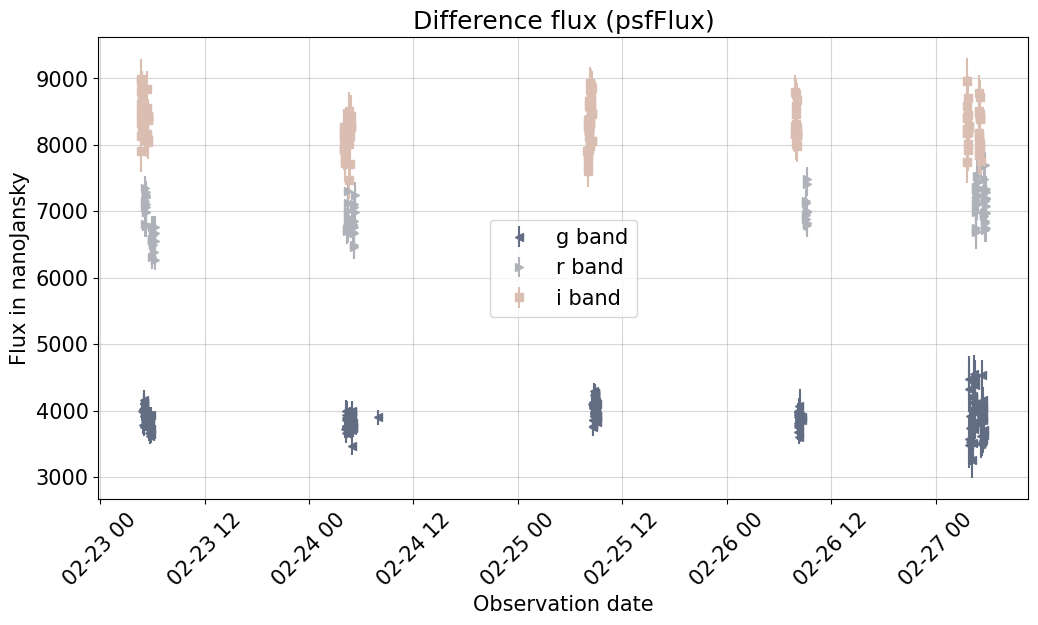

In [9]:
import matplotlib.pyplot as plt

from sso_utils import plot_lightcurve_allbands

plt.rcParams.update({"font.size": 15})

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plot_lightcurve_allbands(
    pdf_obj["r:midpointMjdTai"],
    pdf_obj["r:psfFlux"],
    pdf_obj["r:psfFluxErr"],
    pdf_obj["r:band"],
    ax=ax,
    label="Difference flux (r band)",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Flux in nanoJansky")
ax.set_xlabel("Observation date")
ax.set_title("Difference flux (psfFlux)")
plt.xticks(rotation=45)
plt.show()

The [schema](https://lsst.fink-portal.org/schemas) can be easily accessed using:

In [8]:
import requests

r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/schema",
    json={"endpoint": "/api/v1/sso", "output-format": "json"},
)

schema = r.json()

````{tip} Faster queries
For faster queries, you can select only alert fields of interest by specifying the argument `columns` in your payload:

```python
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={
        "n_or_d": "2015 BC557",
        "columns": "r:midpointMjdTai,r:psfFlux,r:psfFluxErr,r:ra,r:dec",
        "output-format": "json",
    },
)
```
````


In [15]:
def query_fink_sso(name, columns=None):
    payload = {"n_or_d": name, "output-format": "json"}
    if columns is not None:
        payload.update({"columns": columns})
    r = requests.post(
        "https://api.lsst.fink-portal.org/api/v1/sso",
        json=payload,
    )
    return r

In [16]:
%timeit query_fink_sso(name="2015 BC557", columns=None)

1.19 s ± 56.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
%timeit query_fink_sso(name="2015 BC557", columns="r:midpointMjdTai,r:psfFlux,r:psfFluxErr,r:ra,r:dec")

585 ms ± 39.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


You can also retrieve the data for several objects at once:

In [19]:
import io

import pandas as pd
import requests

# ID as string
mylist = ["734394", "K15Bt7C", "Schwarzschilda", "Ukyounodaibu"]

# get alert data for many objects
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={
        "n_or_d": ",".join(mylist),
        "columns": "r:midpointMjdTai,r:psfFlux,r:psfFluxErr,r:ra,r:dec",
        "output-format": "json",
    },
)

# Format output in a DataFrame
pdf_multiple = pd.read_json(io.BytesIO(r.content))

In [22]:
(
    len(pdf_multiple),
    len(pdf_multiple["r:packed_primary_provisional_designation"].unique()),
)

(1518, 3)

## Adding ephemerides from Miriade

````{warning} Slower queries
Beware it adds few seconds delay per API call.
````
You can also attach the ephemerides provided by the [Miriade ephemeride service :lucide-external-link:](https://ssp.imcce.fr/webservices/miriade/api/ephemcc/){target="blank_"}:

In [9]:
import io

import pandas as pd
import requests

# get data for object 2015 BC557
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={"n_or_d": "2015 BC557", "withEphem": True, "output-format": "json"},
)

# Format output in a DataFrame
pdf_eph = pd.read_json(io.BytesIO(r.content))

Where columns not prefixed by `r:` or `f:` are fields returned from Miriade (again, check the schema above).

In [11]:
import numpy as np

deltaRAcosDEC = (
    (pdf_eph["r:ra"] - pdf_eph.RA) * np.cos(np.radians(pdf_eph["r:dec"])) * 3600
)
deltaDEC = (pdf_eph["r:dec"] - pdf_eph.DEC) * 3600

Text(0, 0.5, '$\\Delta$DEC (")')

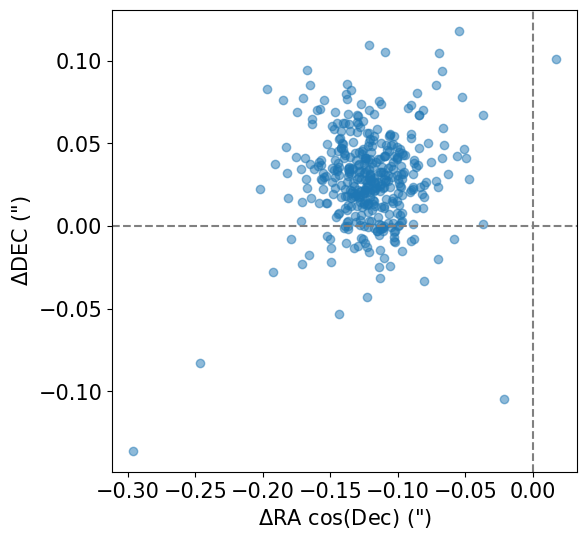

In [19]:
fig = plt.figure(figsize=(6, 6))
plt.scatter(deltaRAcosDEC, deltaDEC, alpha=0.5)
plt.axhline(0, ls="--", color="grey")
plt.axvline(0, ls="--", color="grey")
plt.xlabel(r'$\Delta$RA cos(Dec) (")')
plt.ylabel(r'$\Delta$DEC (")')

## Retrieving cutout stamps

For each alert, you can easily retrieve the associated stamps using the `/api/v1/cutouts` endpoint. For this, you need first to retrieve the `diaSourceId`, and then query for the cutouts:

In [19]:
import io

import requests
from astropy.io import fits

# Get all diaSourceId for object 2015 BC557
# Output is sorted from more recent to least recent
r = requests.post(
    "https://api.lsst.fink-portal.org/api/v1/sso",
    json={"n_or_d": "2015 BC557", "columns": "r:diaSourceId", "output-format": "json"},
)

# Get Science cutouts as FITS for the last 10 alerts
sids = r.json()[0:10]
for sid in sids:
    out = requests.post(
        "https://api.lsst.fink-portal.org/api/v1/cutouts",
        json={
            "diaSourceId": str(sid["r:diaSourceId"]),
            "kind": "Science",
            "output-format": "FITS",
        },
    )
    data = fits.open(io.BytesIO(out.content), ignore_missing_simple=True)
    data.writeto(f"{sid['r:diaSourceId']}_cutoutScience.fits")

In [14]:
# open the last one
cutout = fits.open(f"{sid['r:diaSourceId']}_cutoutScience.fits")

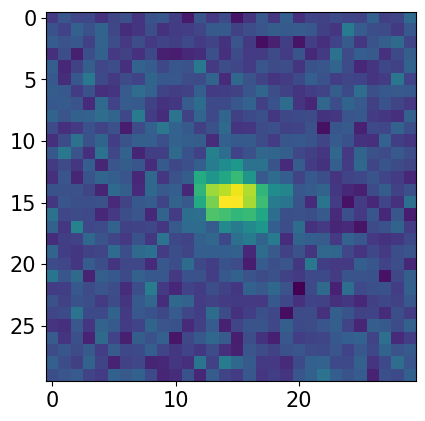

In [16]:
plt.imshow(cutout[0].data)

For more options when downloading images, see the [alert image data](https://doc.lsst.fink-broker.org/services/api/imagesearch/) page. Be careful, each image is about 30KB.

In [21]:
# clean
# !rm *fits

````{danger} Do not abuse!
Although the Fink API gives you access to millions of alerts anonymously, it is not designed to massively download data. If you have a lot of objects to query, you probably want to consider the `/api/v1/ssobulk` endpoint, or you can use the [Data Transfer service](https://doc.lsst.fink-broker.org/services/data_transfer/).
````